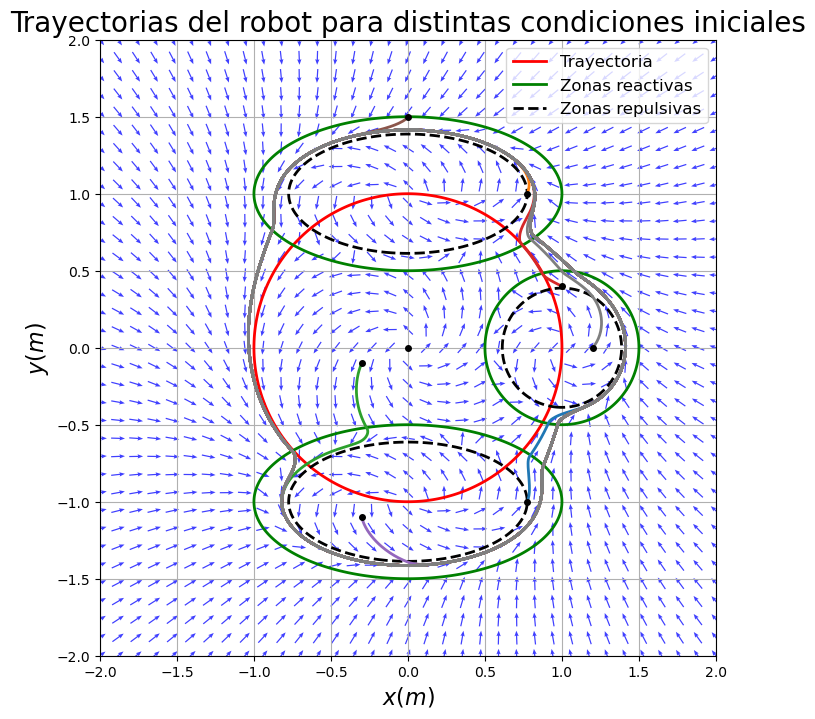

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.lines import Line2D

R = 1.0

def phi(x, y):
    return x**2 + y**2 - R**2

def grad_phi(x, y):
    return np.array([2*x, 2*y])

ox1, oy1 = 0.0, -1.0
ox2, oy2 = 0.0, 1.0
a, b = 1.0, 0.5
# Defino el centro y los semiejes de la elipse para el tercer obstáculo
ox3, oy3 = 1.0, 0.0
a3,b3= 0.5,0.5
beta = 0.0

def varphi1(x, y):
    X = (x - ox1)*np.cos(beta) + (y - oy1)*np.sin(beta)
    Y = (x - ox1)*np.sin(beta) - (y - oy1)*np.cos(beta)
    return X**2/a**2 + Y**2/b**2 - 1

def grad_varphi1(x, y):
    X = (x - ox1)*np.cos(beta) + (y - oy1)*np.sin(beta)
    Y = (x - ox1)*np.sin(beta) - (y - oy1)*np.cos(beta)

    dX = np.array([np.cos(beta), np.sin(beta)])
    dY = np.array([np.sin(beta), -np.cos(beta)])

    return 2*X/a**2*dX + 2*Y/b**2*dY

def varphi2(x, y):
    X = (x - ox2)*np.cos(beta) + (y - oy2)*np.sin(beta)
    Y = (x - ox2)*np.sin(beta) - (y - oy2)*np.cos(beta)
    return X**2/a**2 + Y**2/b**2 - 1

def grad_varphi2(x, y):
    X = (x - ox2)*np.cos(beta) + (y - oy2)*np.sin(beta)
    Y = (x - ox2)*np.sin(beta) - (y - oy2)*np.cos(beta)

    dX = np.array([np.cos(beta), np.sin(beta)])
    dY = np.array([np.sin(beta), -np.cos(beta)])

    return 2*X/a**2*dX + 2*Y/b**2*dY

# Defino la función varphi3 para la elipse rotada y su gradiente correspondiente con un obstaculo en medio

def varphi3(x, y):
    X=(x - ox3)*np.cos(beta) + (y - oy3)*np.sin(beta)
    Y=(x - ox3)*np.sin(beta) - (y - oy3)*np.cos(beta)
    
    return X**2/a3**2 + Y**2/b3**2 - 1

def grad_varphi3(x, y):
    X=(x - ox3)*np.cos(beta) + (y - oy3)*np.sin(beta)
    Y=(x - ox3)*np.sin(beta) - (y - oy3)*np.cos(beta)

    dX = np.array([np.cos(beta), np.sin(beta)])
    dY = np.array([np.sin(beta), -np.cos(beta)])

    return 2*X/a3**2*dX + 2*Y/b3**2*dY

c = -0.4
l1 = 0.1
l2 = 0.1

def t_Q1(x, y):
    v = varphi1(x, y)
    if v <= c:
        return 0.0
    return np.exp(l1 / (c - v))

def u_R1(x, y):
    v = varphi1(x, y)
    if v >= 0:
        return 0.0
    return np.exp(l2 / v)

def t_Q2(x, y):
    v = varphi2(x, y)
    if v <= c:
        return 0.0
    return np.exp(l1 / (c - v))

def u_R2(x, y):
    v = varphi2(x, y)
    if v >= 0:
        return 0.0
    return np.exp(l2 / v)
    
# Agrego las funciones de evitación para el tercer obstáculo
def t_Q3(x, y):
    v = varphi3(x, y)
    if v <= c:
        return 0.0
    return np.exp(l1 / (c - v))

def u_R3(x, y):
    v = varphi3(x, y)
    if v >= 0:
        return 0.0
    return np.exp(l2 / v)

kp = 1.0
kr = 1.0
# He mantenido kr3 igual a 1.0 para el tercer obstáculo, pero puedes ajustarlo si deseas que tenga una influencia diferente en la dinámica del sistema.
kr3= 1.0
E = np.array([[0, -1],
              [1,  0]])

def normalize(v):
    n = np.linalg.norm(v)
    if n < 1e-8:
        return np.zeros_like(v)
    return v / n

def chi_P(x, y):
    g = grad_phi(x, y)
    return E @ g - kp * phi(x, y) * g

def chi_R1(x, y):
    g = grad_varphi1(x, y)
    return E @ g - kr * varphi1(x, y) * g

def chi_R2(x, y):
    g = grad_varphi2(x, y)
    return E @ g - kr * varphi2(x, y) * g

def chi_R3(x, y):
    g = grad_varphi3(x, y)
    return E @ g - kr3 * varphi3(x, y) * g

def chi_composite(t, z):
    x, y = z

    wP = t_Q1(x, y) * t_Q2(x, y)*t_Q3(x, y)
    wR1 = u_R1(x, y)
    wR2 = u_R2(x, y)
    wR3 = u_R3(x, y) # Añado el peso para el tercer obstáculo

    return (
        wP * normalize(chi_P(x, y))
        + wR1 * normalize(chi_R1(x, y))
        + wR2 * normalize(chi_R2(x, y))
        + wR3 * normalize(chi_R3(x, y)) #Añado la contribución del tercer obstáculo al campo vectorial compuesto
    )

initial_conditions = [
    [np.sqrt(0.6), -1],
    [np.sqrt(0.6), 1],
    [-0.3, -0.1],
    [1,0.4],
    [-0.3, -1.1],
    [0,1.5],
    [0,0]
]

t_span = (0, 40)
t_eval = np.linspace(t_span[0], t_span[1], 3000)

solutions = []

for z0 in initial_conditions:
    sol = solve_ivp(
        chi_composite,
        t_span,
        z0,
        t_eval=t_eval,
        rtol=1e-8,
        atol=1e-10
    )
    solutions.append(sol)

x = np.linspace(-2, 2, 400)
y = np.linspace(-2, 2, 400)
X, Y = np.meshgrid(x, y)

Phi = phi(X, Y)
Varphi1 = varphi1(X, Y)
Varphi2 = varphi2(X, Y)
Varphi3 = varphi3(X, Y)
xq = np.linspace(-2, 2, 35)
yq = np.linspace(-2, 2, 35)
Xq, Yq = np.meshgrid(xq, yq)

U = np.zeros_like(Xq)
V = np.zeros_like(Yq)

for i in range(Xq.shape[0]):
    for j in range(Xq.shape[1]):
        dx, dy = chi_composite(0, [Xq[i, j], Yq[i, j]])
        U[i, j] = dx
        V[i, j] = dy

N = np.sqrt(U**2 + V**2)

U_plot = np.divide(U, N, out=np.zeros_like(U), where=N > 1e-8)
V_plot = np.divide(V, N, out=np.zeros_like(V), where=N > 1e-8)

arrow_length = 0.09
U_plot *= arrow_length
V_plot *= arrow_length

plt.figure(figsize=(8, 8))

plt.quiver(
    Xq, Yq, U_plot, V_plot,
    angles='xy',
    scale_units='xy',
    scale=1,
    width=0.002,
    headwidth=3.5,
    headlength=4.5,
    headaxislength=4,
    pivot='middle',
    color='blue',
    alpha=0.75
)

plt.contour(X, Y, Phi, levels=[0], colors='red', linewidths=2)
plt.contour(X, Y, Varphi1, levels=[0], colors='green', linewidths=2)
plt.contour(X, Y, Varphi2, levels=[0], colors='green', linewidths=2)
plt.contour(X, Y, Varphi3, levels=[0], colors='green', linewidths=2)
plt.contour(X, Y, Varphi1, levels=[c], colors='black', linestyles='--', linewidths=2)
plt.contour(X, Y, Varphi2, levels=[c], colors='black', linestyles='--', linewidths=2)
plt.contour(X, Y, Varphi3, levels=[c], colors='black', linestyles='--', linewidths=2)

for sol in solutions:
    plt.plot(sol.y[0], sol.y[1], linewidth=2)

for z0 in initial_conditions:
    plt.plot(z0[0], z0[1], 'ko', markersize=4)

ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)

plt.grid(True)
plt.xlabel('$x (m)$', fontsize=16)
plt.ylabel('$y (m)$', fontsize=16)
plt.title('Trayectorias del robot para distintas condiciones iniciales', fontsize=20)
leyenda = [
    Line2D([0], [0], color="red", lw=2, label="Trayectoria"),
    Line2D([0], [0], color="green", lw=2, label="Zonas reactivas"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="Zonas repulsivas"),
]

plt.legend(handles=leyenda,fontsize=12)
plt.savefig("simulacion.pdf", bbox_inches="tight")
plt.show()

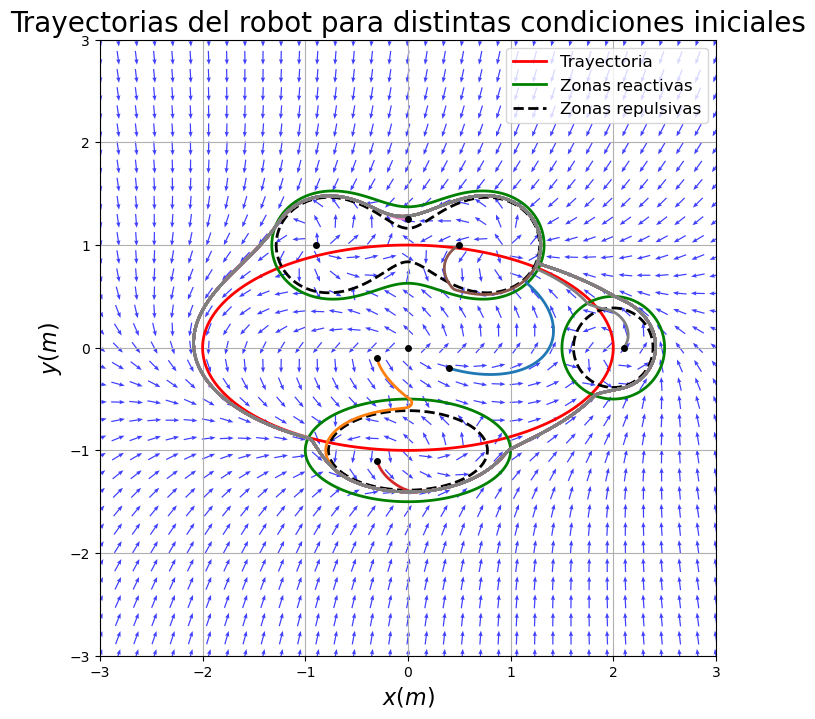

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.lines import Line2D

ox=oy=0
a, b = 2.0, 1.0

def phi(x, y):
    X = (x - ox)*np.cos(beta) + (y - oy)*np.sin(beta)
    Y = (x - ox)*np.sin(beta) - (y - oy)*np.cos(beta)
    
    return X**2/a**2 + Y**2/b**2 - 1

def grad_phi(x, y):
    X = (x - ox)*np.cos(beta) + (y - oy)*np.sin(beta)
    Y = (x - ox)*np.sin(beta) - (y - oy)*np.cos(beta)

    dX = np.array([np.cos(beta), np.sin(beta)])
    dY = np.array([np.sin(beta), -np.cos(beta)])

    return 2*X/a**2*dX + 2*Y/b**2*dY

#ELIPSE SUPERIOR
ox1, oy1 = 0.0, -1.0
a1, b1 = 1.0, 0.5
#OVALO DE CASSINI

# Defino el centro y los semiejes de la elipse para el tercer obstáculo
ox3, oy3 = 2.0, 0.0
a3,b3= 0.5,0.5
beta = 0.0

def varphi1(x, y):
    X = (x - ox1)*np.cos(beta) + (y - oy1)*np.sin(beta)
    Y = (x - ox1)*np.sin(beta) - (y - oy1)*np.cos(beta)
    return X**2/a1**2 + Y**2/b1**2 - 1

def grad_varphi1(x, y):
    X = (x - ox1)*np.cos(beta) + (y - oy1)*np.sin(beta)
    Y = (x - ox1)*np.sin(beta) - (y - oy1)*np.cos(beta)

    dX = np.array([np.cos(beta), np.sin(beta)])
    dY = np.array([np.sin(beta), -np.cos(beta)])

    return 2*X/a**2*dX + 2*Y/b**2*dY

def varphi2(x, y):
    return ((x-0.9)**2+(y-1)**2)*((x+0.9)**2+(y-1)**2)-0.9

def grad_varphi2(x, y):
    A = (x - 0.9)**2 + (y - 1)**2
    B = (x + 0.9)**2 + (y - 1)**2

    dphidx = 2*(x - 0.9)*B + 2*(x + 0.9)*A
    dphidy = 2*(y - 1)*(A + B)

    return np.array([dphidx, dphidy])

# Defino la función varphi3 para la elipse rotada y su gradiente correspondiente con un obstaculo en medio

def varphi3(x, y):
    X=(x - ox3)*np.cos(beta) + (y - oy3)*np.sin(beta)
    Y=(x - ox3)*np.sin(beta) - (y - oy3)*np.cos(beta)
    
    return X**2/a3**2 + Y**2/b3**2 - 1

def grad_varphi3(x, y):
    X=(x - ox3)*np.cos(beta) + (y - oy3)*np.sin(beta)
    Y=(x - ox3)*np.sin(beta) - (y - oy3)*np.cos(beta)

    dX = np.array([np.cos(beta), np.sin(beta)])
    dY = np.array([np.sin(beta), -np.cos(beta)])

    return 2*X/a3**2*dX + 2*Y/b3**2*dY

c = -0.4
c2=-0.2
l1 = 0.05
l2 = 0.05

def t_Q1(x, y):
    v = varphi1(x, y)
    if v <= c:
        return 0.0
    return np.exp(l1 / (c - v))

def u_R1(x, y):
    v = varphi1(x, y)
    if v >= 0:
        return 0.0
    return np.exp(l2 / v)

def t_Q2(x, y):
    v = varphi2(x, y)
    if v <= c2:
        return 0.0
    return np.exp(l1 / (c2 - v))

def u_R2(x, y):
    v = varphi2(x, y)
    if v >= 0:
        return 0.0
    return np.exp(l2 / v)
    
# Agrego las funciones de evitación para el tercer obstáculo
def t_Q3(x, y):
    v = varphi3(x, y)
    if v <= c:
        return 0.0
    return np.exp(l1 / (c - v))

def u_R3(x, y):
    v = varphi3(x, y)
    if v >= 0:
        return 0.0
    return np.exp(l2 / v)

kp = 1.0
kr = 1.0
kr2=3
# He mantenido kr3 igual a 1.0 para el tercer obstáculo, pero puedes ajustarlo si deseas que tenga una influencia diferente en la dinámica del sistema.
kr3= 1.0
E = np.array([[0, -1],
              [1,  0]])

def normalize(v):
    n = np.linalg.norm(v)
    if n < 1e-8:
        return np.zeros_like(v)
    return v / n

def chi_P(x, y):
    g = grad_phi(x, y)
    return E @ g - kp * phi(x, y) * g

def chi_R1(x, y):
    g = grad_varphi1(x, y)
    return E @ g - kr * varphi1(x, y) * g

def chi_R2(x, y):
    g = grad_varphi2(x, y)
    return E @ g - kr2 * varphi2(x, y) * g

def chi_R3(x, y):
    g = grad_varphi3(x, y)
    return E @ g - kr3 * varphi3(x, y) * g

def chi_composite(t, z):
    x, y = z

    wP = t_Q1(x, y) * t_Q2(x, y)*t_Q3(x, y)
    wR1 = u_R1(x, y)
    wR2 = u_R2(x, y)
    wR3 = u_R3(x, y) # Añado el peso para el tercer obstáculo

    return (
        wP * normalize(chi_P(x, y))
        + wR1 * normalize(chi_R1(x, y))
        + wR2 * normalize(chi_R2(x, y))
        + wR3 * normalize(chi_R3(x, y)) #Añado la contribución del tercer obstáculo al campo vectorial compuesto
    )

initial_conditions = [
   [0.4, -0.2],
    [-0.3, -0.1],
    [-0.9, 1.0],
    [-0.3, -1.1],
    [0,0],
    [0.5,1.0],
    [0,1.25],
    [2.1,0]
]

t_span = (0, 40)
t_eval = np.linspace(t_span[0], t_span[1], 3000)

solutions = []

for z0 in initial_conditions:
    sol = solve_ivp(
        chi_composite,
        t_span,
        z0,
        t_eval=t_eval,
        rtol=1e-8,
        atol=1e-10
    )
    solutions.append(sol)
    
x = np.linspace(-3, 3, 400)
y = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x, y)

Phi = phi(X, Y)
Varphi1 = varphi1(X, Y)
Varphi2 = varphi2(X, Y)
Varphi3 = varphi3(X, Y)
xq = np.linspace(-3, 3, 35)
yq = np.linspace(-3, 3, 35)
Xq, Yq = np.meshgrid(xq, yq)

U = np.zeros_like(Xq)
V = np.zeros_like(Yq)

for i in range(Xq.shape[0]):
    for j in range(Xq.shape[1]):
        dx, dy = chi_composite(0, [Xq[i, j], Yq[i, j]])
        U[i, j] = dx
        V[i, j] = dy

N = np.sqrt(U**2 + V**2)

U_plot = np.divide(U, N, out=np.zeros_like(U), where=N > 1e-8)
V_plot = np.divide(V, N, out=np.zeros_like(V), where=N > 1e-8)

arrow_length = 0.135
U_plot *= arrow_length
V_plot *= arrow_length

plt.figure(figsize=(8, 8))

plt.quiver(
    Xq, Yq, U_plot, V_plot,
    angles='xy',
    scale_units='xy',
    scale=1,
    width=0.002,
    headwidth=3.5,
    headlength=4.5,
    headaxislength=4,
    pivot='middle',
    color='blue',
    alpha=0.75
)

plt.contour(X, Y, Phi, levels=[0], colors='red', linewidths=2)
plt.contour(X, Y, Varphi1, levels=[0], colors='green', linewidths=2)
plt.contour(X, Y, Varphi2, levels=[0], colors='green', linewidths=2)
plt.contour(X, Y, Varphi3, levels=[0], colors='green', linewidths=2)
plt.contour(X, Y, Varphi1, levels=[c], colors='black', linestyles='--', linewidths=2)
plt.contour(X, Y, Varphi2, levels=[c2], colors='black', linestyles='--', linewidths=2)
plt.contour(X, Y, Varphi3, levels=[c], colors='black', linestyles='--', linewidths=2)

for sol in solutions:
    plt.plot(sol.y[0], sol.y[1], linewidth=2)

for z0 in initial_conditions:
    plt.plot(z0[0], z0[1], 'ko', markersize=4)

ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)

plt.grid(True)
plt.xlabel('$x (m)$', fontsize=16)
plt.ylabel('$y (m)$', fontsize=16)
plt.title('Trayectorias del robot para distintas condiciones iniciales', fontsize=20)
leyenda = [
    Line2D([0], [0], color="red", lw=2, label="Trayectoria"),
    Line2D([0], [0], color="green", lw=2, label="Zonas reactivas"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="Zonas repulsivas"),
]

plt.legend(handles=leyenda,fontsize=12)
plt.savefig("simulacion.pdf", bbox_inches="tight")
plt.show()

